In [2]:
def f(x):
    return x**2+3*x +3

In [3]:
h = 0.001
x = 100
(f(x+h) - f(x))/h # 2*100 + 3

203.0010000016773

In [4]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h) # with respect to c 

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [5]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h) # with respect to b

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [48]:
import comp_graph_node
import importlib

importlib.reload(comp_graph_node)

from comp_graph_node import ComputationGraphNode

In [34]:
# a = ComputationGraphNode(1,label = 'a') 
# b = ComputationGraphNode(2,label = 'b')
# c = ComputationGraphNode(3,label = 'c')
# d = ComputationGraphNode(4,label = 'd')
# print(a)
# print(b)
# print(c)
# print(d)
# l = a + b*d + c*d*a
# print(l)

a = ComputationGraphNode(2, label='a')
b = ComputationGraphNode(3, label='b')
c = ComputationGraphNode(4, label='c')

y = a * b          # y = 6
z = y * c          # z = 24
l = y + z          # l = 30


print(l)

 - 30


In [35]:
#  l = a + b + c*d ==>  dl/da ==>  1 + 0 + 0 -> how to simulate this 
#  l = a + b*(c+d*c) + c*d ==>  dl/dc ==>  0 + b + b*d + d -> how to simulate this 
#  l = a + c*c*d ==>  dl/dc ==>  0 + 2*c*d -> how to simulate this 

# okay ig dont complicate just think of it as y = g(x)*f(x) => dy/dx = d(g(x)/dx)*f(x) + g(x)*(d(f(x)/dx)

In [36]:
# NOTE copy pasted from karpathy 

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

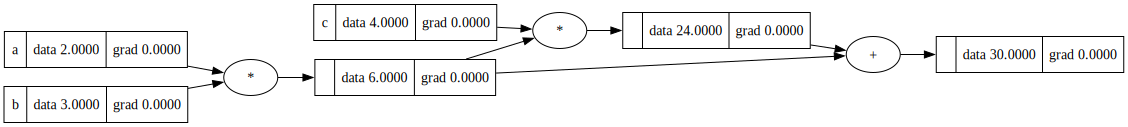

In [37]:
draw_dot(l)

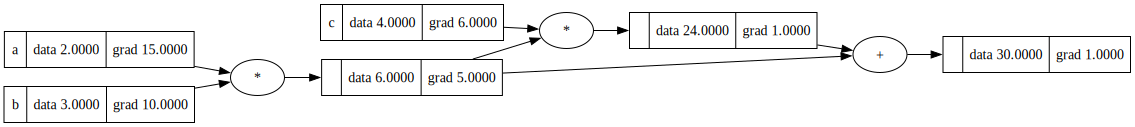

In [38]:
l.grad = 1.0
l.dfs_topo_backward()
draw_dot(l)

In [50]:
x1 = ComputationGraphNode(2, label='x1')
x2 = ComputationGraphNode(3, label='x2')
w1 = ComputationGraphNode(None,label='w1')
w2 = ComputationGraphNode(None,label='w2')
b = ComputationGraphNode(None,label='b')
y = w1*x1 + w2*x2 + b

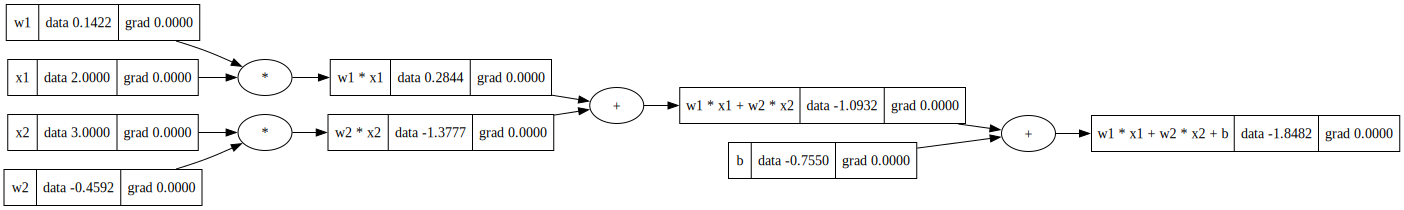

In [51]:
draw_dot(y)

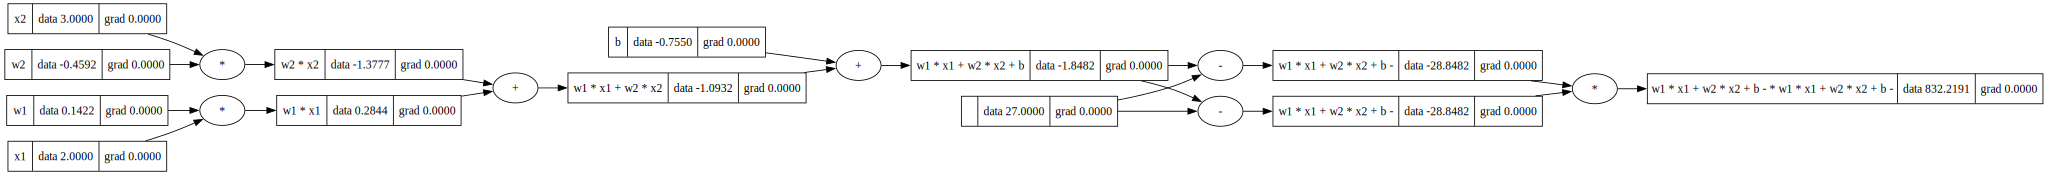

In [52]:
# let simulate 4x + 3y + 10
# for x = 2 , y = 3 ==> y truth = 27
y_true = ComputationGraphNode(27)
loss = (y - y_true) * (y - y_true) # MSE Loss 
draw_dot(loss)

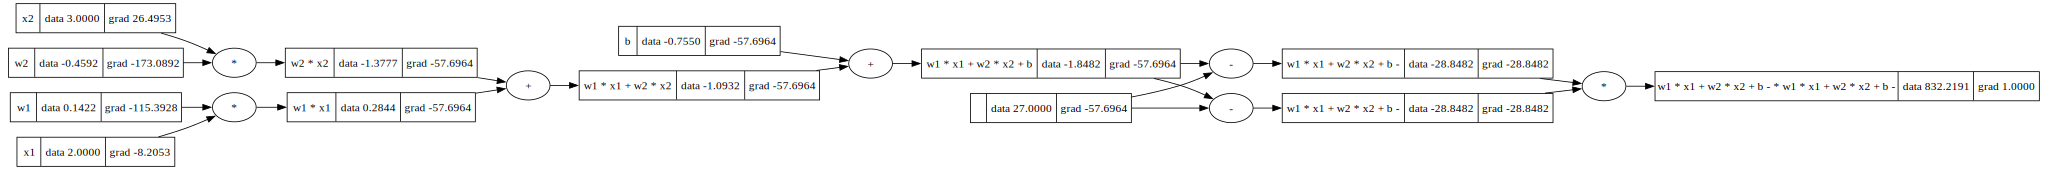

In [53]:
loss.dfs_topo_backward()
draw_dot(loss)

In [ ]:
# Now next to simulate  w1 = w1 - n*dl/dw